In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import pandas
from pathlib import Path

from video import filter_frame, change_color_representation, extract_pixels_in_mask, normalize_brightness, set_frame
from mask_creation import reduced_frame_polygon, create_mask

import mask_creation
import video

from pynput import mouse

In [2]:
figure_dir          = Path(os.getcwd()) / "figures"
# data_dir            = Path(os.getcwd()) / "video-data"
data_dir            = Path("..") / "data"
polygon_dir         = Path(os.getcwd()) / "polygons"
case_videos_dir     = Path(os.getcwd()) / "case_videos"
segnet_output_dir   = Path(os.getcwd()) / "segnet_output"
scan_output_dir     = Path(os.getcwd()) / "scan_output"
reduced_video_dir   = Path(os.getcwd()) / "reduced_video_data"
video_filename = "Video_Test_F2787_125743_01_VIDCKPT_sec.mpg"


In [3]:
cap = cv2.VideoCapture(data_dir / video_filename)

In [4]:

# 1. Define the mouse callback function
def click_event(event, x, y, flags, param):
    # Check if the event is a left mouse button click
    if event == cv2.EVENT_LBUTTONDOWN:

        # cv2.drawMarker(frame, (x, y))
        print(f"Clicked coordinates: X: {x}, Y: {y}")
        storage.append((x, y))     
        cv2.drawMarker(frame, (x, y), (0, 255, 0), 10)
    


def draw()->None:
    cap = cv2.VideoCapture(data_dir / video_filename)
    # pipe_mask = mask_creation.get_mask(cap, "pipe_small", plot_mask=True, figure_dir=figure_dir)
    print(f"{figure_dir.__str__() = }")
    start = 0
    end = 1
    i = 0
    set_frame(cap, i)
    global storage, frame
    storage = []

    cv2.namedWindow("RF")
    cv2.setMouseCallback("RF", click_event)

    while cap.isOpened():

        ret, frame = cap.read()
        if not ret: break

        print(f"Showing frame {i}")
        for x, y in storage:
            print(f"drawing ({x, y})")
            cv2.drawMarker(frame, (x, y), (0, 255, 0), 10)
        # i += 1

        cv2.imshow("RF", frame)
        key = cv2.waitKey(0)
        # quit
        if key == ord("q"):
            exit()
            break

        elif key == ord("s"):
            i = int(input("new frame: "))
            set_frame(cap, i)

        if key == ord("g"):
            cv2.imwrite("figures\\first frame with markers.png", frame)

        if i == end:
            break

    cv2.destroyAllWindows()



    return 
# draw()

In [37]:
def load_markers():
    with open("geometric_markers.txt") as doc:
        markers = []

        for line in doc:
            _, x_str, y_str = line.strip().split()
            x = x_str.strip("()").strip(",")
            y = y_str.strip("()").strip(",")
            x = int(x)
            y = int(y)
            markers.append((x, y))
        markers = np.array(markers)
        print(f"{markers.shape = }")
        red_sticker = markers[-4:, :]
        print(f"{red_sticker.shape = }")
        segments = {
            "red_sticker": red_sticker
        }
        for i in range(0, markers.shape[0]- 4, 2):
            segments[i//2] = markers[i: i+2]
        return segments
segments = load_markers()


markers.shape = (18, 2)
red_sticker.shape = (4, 2)


In [46]:
dimensions = {
    "red_sticker": (5.1e-2, 2.3e-2),
    "yellow_black": 1e-2
}

Red sticker
 - x_dist_far: 27.5 pixels / cm
 - x_dist_close: 27.9 pixels / cm
 - y_dist_left: 28.5 pixels / cm
 - x_dist_right: 28.4 pixels / cm
segment 0: 12.0 pixels / cm
segment 1: 16.4 pixels / cm
segment 2: 15.0 pixels / cm
segment 3: 15.7 pixels / cm
segment 4: 24.0 pixels / cm
segment 5: 23.3 pixels / cm
segment 6: 24.4 pixels / cm


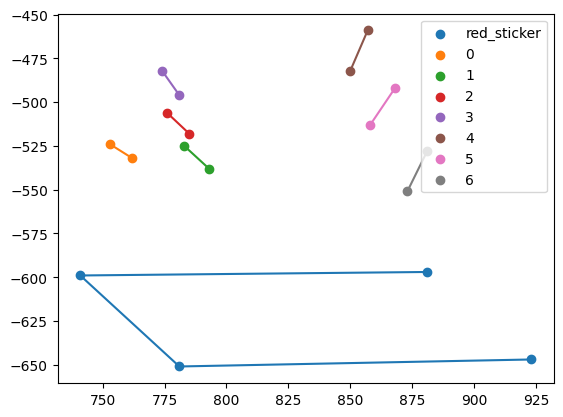

In [61]:
fig, ax = plt.subplots()
for key in segments.keys():
    # print(f"{key = }")
    points = segments[key]
    ax.scatter(points[:, 0], -points[:, 1], label=key)
    ax.plot(points[:, 0], -points[:, 1])
    if key == "red_sticker":
        x_dist_far = np.linalg.norm(points[1] - points[0])
        x_dist_close = np.linalg.norm(points[3] - points[2])
        y_dist_left = np.linalg.norm(points[2] - points[1])
        y_dist_right = np.linalg.norm(points[0] - points[3])
        true_x_dist = dimensions["red_sticker"][0]
        true_y_dist = dimensions["red_sticker"][1]
        print(f"Red sticker")
        print(f" - x_dist_far: {x_dist_far / true_x_dist*1e-2:.3} pixels / cm")
        print(f" - x_dist_close: {x_dist_close / true_x_dist*1e-2:.3} pixels / cm")
        print(f" - y_dist_left: {y_dist_left / true_y_dist*1e-2:.3} pixels / cm")
        print(f" - x_dist_right: {y_dist_right / true_y_dist*1e-2:.3} pixels / cm")
    else:
        pixel_dist = np.linalg.norm(points[1] - points[0])
        true_dist = dimensions["yellow_black"]
        print(f"segment {key}: {pixel_dist / true_dist * 1e-2:.3} pixels / cm")

ax.legend(loc="upper right")
# ax.set_aspect("equal")